<a href="https://colab.research.google.com/github/Manojmp7676/DEEP_LEARNING_FILES/blob/main/Deep_Learning_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets

In [3]:
from datasets import load_dataset
import pandas as pd

In [7]:
raw_dataset=load_dataset("wangrongsheng/ag_news")

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [12]:
df=pd.DataFrame(raw_dataset["train"])
print(df.head())

                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


# Task
The user wants to build an RNN model for text classification. The task involves loading the `ag_news` dataset, preprocessing the text data (cleaning, tokenization, padding), defining and compiling an RNN model, training the model, and finally evaluating its accuracy.

## Split Data

### Subtask:
Split the preloaded DataFrame (`df`) into training and testing sets for text features and corresponding labels. This is a crucial step before cleaning, tokenizing, and feeding the data into the model.


**Reasoning**:
I need to import the `train_test_split` function to split the data and then apply it to the `df` DataFrame, separating the 'text' column as features and 'label' as target, and splitting into train and test sets.



In [24]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (96000,)
Shape of X_test: (24000,)
Shape of y_train: (96000,)
Shape of y_test: (24000,)


## Clean and Normalize Text

### Subtask:
Preprocess the 'text' column for both training (`X_train`) and testing (`X_test`) sets. This involves converting all text to lowercase, removing punctuation, special characters, and numbers to reduce noise and standardize the input for the model.


**Reasoning**:
I need to define a text cleaning function and then apply it to both `X_train` and `X_test` to preprocess the text data as per the instructions.



In [25]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

X_train_cleaned = X_train.apply(clean_text)
X_test_cleaned = X_test.apply(clean_text)

print("Original X_train sample:")
print(X_train.head())
print("\nCleaned X_train sample:")
print(X_train_cleaned.head())

print("\nOriginal X_test sample:")
print(X_test.head())
print("\nCleaned X_test sample:")
print(X_test_cleaned.head())

Original X_train sample:
53541     Support independent journalism Please donate n...
41728     Stingy Falcons Defense Key to 3-0 Start (AP) A...
74819     Pak, Sri Lanka lock horns in Karachi Test toda...
106459    Villages tune in to digital trial Two villages...
63062     South African gold groups poised for merger A ...
Name: text, dtype: object

Cleaned X_train sample:
53541     support independent journalism please donate n...
41728     stingy falcons defense key to  start ap ap  ma...
74819     pak sri lanka lock horns in karachi test today...
106459    villages tune in to digital trial two villages...
63062     south african gold groups poised for merger a ...
Name: text, dtype: object

Original X_test sample:
71787    BBC set for major shake-up, claims newspaper L...
67218    Marsh averts cash crunch Embattled insurance b...
54066    Jeter, Yankees Look to Take Control (AP) AP - ...
7168     Flying the Sun to Safety When the Genesis caps...
29618    Stocks Seen Flat as Nortel a

## Tokenize Text

### Subtask:
Utilize a Keras Tokenizer to convert the cleaned text data into sequences of integers. The tokenizer will be fitted on the training data to build the vocabulary, and then both training and testing text will be transformed into numerical sequences.


**Reasoning**:
Import `Tokenizer`, initialize it, fit it on `X_train_cleaned` and transform both `X_train_cleaned` and `X_test_cleaned` into sequences as per the instructions.



In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')

tokenizer.fit_on_texts(X_train_cleaned)

X_train_sequences = tokenizer.texts_to_sequences(X_train_cleaned)
X_test_sequences = tokenizer.texts_to_sequences(X_test_cleaned)

print("Original Cleaned X_train sample (first 5):")
for i in range(5):
    print(f"  Text: {X_train_cleaned.iloc[i]}")
    print(f"  Sequence: {X_train_sequences[i]}")

print("\nOriginal Cleaned X_test sample (first 5):")
for i in range(5):
    print(f"  Text: {X_test_cleaned.iloc[i]}")
    print(f"  Sequence: {X_test_sequences[i]}")

Original Cleaned X_train sample (first 5):
  Text: support independent journalism please donate now to our fall fund drive to help the monitor bring you insightful quality journalism
  Sequence: [371, 1913, 1, 4830, 1, 163, 3, 1109, 382, 704, 837, 3, 193, 2, 3249, 979, 158, 1, 3331, 1]
  Text: stingy falcons defense key to  start ap ap  maybe the atlanta falcons arent a oneman team after all while michael vick commands most of the attention the defense should get the bulk of the credit for the falcons  start   their best since 
  Sequence: [1, 3717, 469, 357, 3, 265, 26, 26, 2984, 2, 890, 3717, 5305, 4, 1, 101, 29, 116, 197, 549, 7109, 1, 127, 5, 2, 2285, 2, 469, 366, 208, 2, 7631, 5, 2, 1063, 9, 2, 3717, 265, 34, 466, 233]
  Text: pak sri lanka lock horns in karachi test today karachi october  online bruised and battered pakistan cricket team will take on sri lanka to avenge the defeat of first test in final and decisive test of two match series here at national cricket stadium today 

## Pad and Truncate Sequences

### Subtask:
Apply padding and truncation to the tokenized sequences for both training and testing sets. This ensures all input sequences have a uniform length, which is a requirement for recurrent neural networks, aligning with your Step 4.


**Reasoning**:
First, I'll calculate the lengths of all sequences in `X_train_sequences` and `X_test_sequences` and then determine a suitable `maxlen` by inspecting the distribution, specifically the 90th percentile, to ensure most sequences are covered without excessive padding. This will help us determine the appropriate `maxlen` for padding.



In [27]:
import numpy as np

train_sequence_lengths = [len(seq) for seq in X_train_sequences]

test_sequence_lengths = [len(seq) for seq in X_test_sequences]

maxlen = int(np.percentile(train_sequence_lengths, 90))

print(f"Max sequence length in X_train_sequences: {max(train_sequence_lengths)}")
print(f"Average sequence length in X_train_sequences: {np.mean(train_sequence_lengths):.2f}")
print(f"90th percentile of sequence lengths in X_train_sequences: {maxlen}")

Max sequence length in X_train_sequences: 176
Average sequence length in X_train_sequences: 36.72
90th percentile of sequence lengths in X_train_sequences: 47


**Reasoning**:
Now that `maxlen` has been determined, I need to apply padding and truncation to both `X_train_sequences` and `X_test_sequences` using the `pad_sequences` function from Keras to ensure all sequences have a uniform length. This aligns with the subtask's objective of preparing the data for the RNN model.



In [28]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxlen, padding='post', truncating='post')

print(f"Shape of X_train_padded: {X_train_padded.shape}")
print(f"Shape of X_test_padded: {X_test_padded.shape}")

Shape of X_train_padded: (96000, 47)
Shape of X_test_padded: (24000, 47)


## One-Hot Encode Labels

### Subtask:
Convert the numerical 'label' column in both the training and testing sets into one-hot encoded categorical vectors. This prepares the target variable in a format suitable for classification tasks with a softmax output layer, as described in your Step 5.


**Reasoning**:
I need to import the `to_categorical` function from `tensorflow.keras.utils` and then apply it to `y_train` and `y_test` to convert them into one-hot encoded vectors, as specified in the instructions. Finally, I will print the shapes to verify the transformation.



In [29]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(y_train))

y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print(f"Original y_train shape: {y_train.shape}")
print(f"One-hot encoded y_train shape: {y_train_one_hot.shape}")
print(f"Original y_test shape: {y_test.shape}")
print(f"One-hot encoded y_test shape: {y_test_one_hot.shape}")

Original y_train shape: (96000,)
One-hot encoded y_train shape: (96000, 4)
Original y_test shape: (24000,)
One-hot encoded y_test shape: (24000, 4)


## Define RNN Model Architecture

### Subtask:
Construct the RNN model using Keras. This will involve stacking an Embedding Layer, a SimpleRNN Layer, and a Dense Output Layer with softmax activation, as outlined in your Step 6.


**Reasoning**:
I need to import the necessary Keras layers and then define the RNN model architecture as per the instructions, including the Embedding, SimpleRNN, and Dense layers.



In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=max_words, output_dim=100, input_length=maxlen),
    SimpleRNN(units=100),
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code produced a warning about the deprecated `input_length` argument in the `Embedding` layer. I will remove this argument from the `Embedding` layer definition to fix the warning and ensure the model definition is up-to-date with the Keras API.



In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=max_words, output_dim=100),
    SimpleRNN(units=100),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile and Train Model

### Subtask:
Compile the defined RNN model by specifying an optimizer (e.g., 'adam') and a suitable loss function for multi-class classification. Then, train the model using the prepared training data, specifying the number of epochs and a validation split.


**Reasoning**:
Compile the model with 'adam' optimizer, 'categorical_crossentropy' loss, and 'accuracy' metric. Then, train the model using `X_train_padded` and `y_train_one_hot` for 5 epochs, with a batch size of 32 and a 0.2 validation split.



In [33]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_padded, y_train_one_hot, epochs=2, batch_size=32, validation_split=0.2)

print("Model training complete.")

Epoch 1/2
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 70s 28ms/step - accuracy: 0.7465 - loss: 0.6690 - val_accuracy: 0.4179 - val_loss: 1.5122
Epoch 2/2
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.6946 - loss: 0.8241 - val_accuracy: 0.7759 - val_loss: 0.6240
Model training complete.


## Evaluate Model

### Subtask:
Evaluate the trained RNN model on the test dataset to assess its performance. This involves calculating the loss and accuracy metrics on `X_test_padded` and `y_test_one_hot`.

**Reasoning**:
I need to evaluate the model using the `evaluate` method, passing in the padded test features and one-hot encoded test labels. This will provide the loss and accuracy of the model on unseen data.

In [34]:
loss, accuracy = model.evaluate(X_test_padded, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.6271
Test Accuracy: 0.7758


## Visualize Training History

### Subtask:
Plot the training and validation accuracy and loss over the epochs to visualize the model's learning process and identify potential overfitting or underfitting.

**Reasoning**:
I need to import `matplotlib.pyplot` to create plots. I will then plot the `accuracy` and `val_accuracy` from the `history` object obtained during model training, as well as the `loss` and `val_loss`. This will provide a visual representation of the model's performance during training.

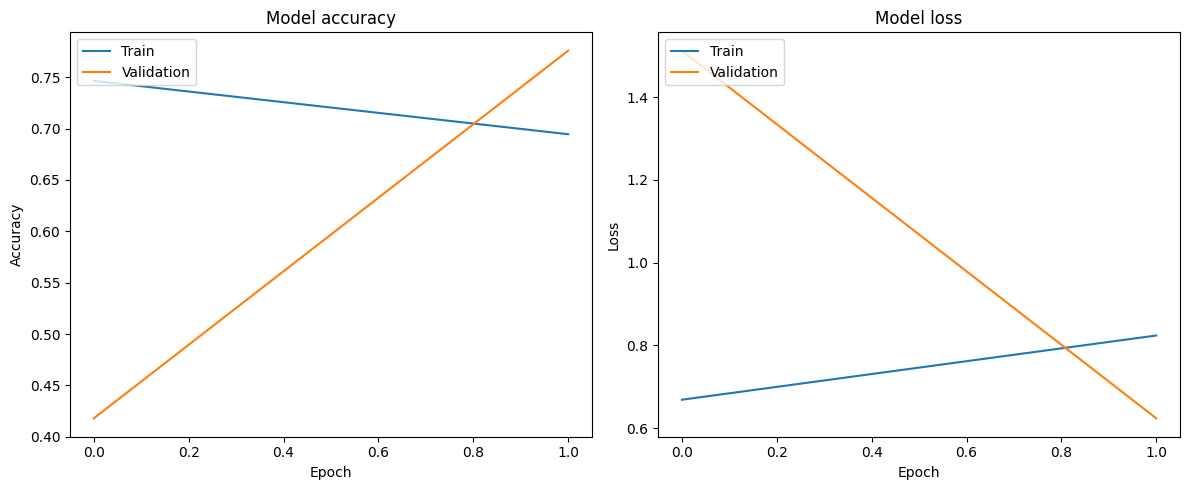

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()